<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/8_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Install required packages for Streamlit deployment
!pip install -q streamlit pyngrok joblib

In [23]:
# Load the diabetes dataset and required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,classification_report,confusion_matrix
import joblib
df=pd.read_csv("diabetes (1).csv")
print("Dataset Shape:",df.shape)
print(df.head())

Dataset Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [24]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [25]:
# Perform exploratory data analysis
print("Data Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:",df.duplicated().sum())
print("\nTarget Distribution:")
print(df["Outcome"].value_counts())

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Summary Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  1

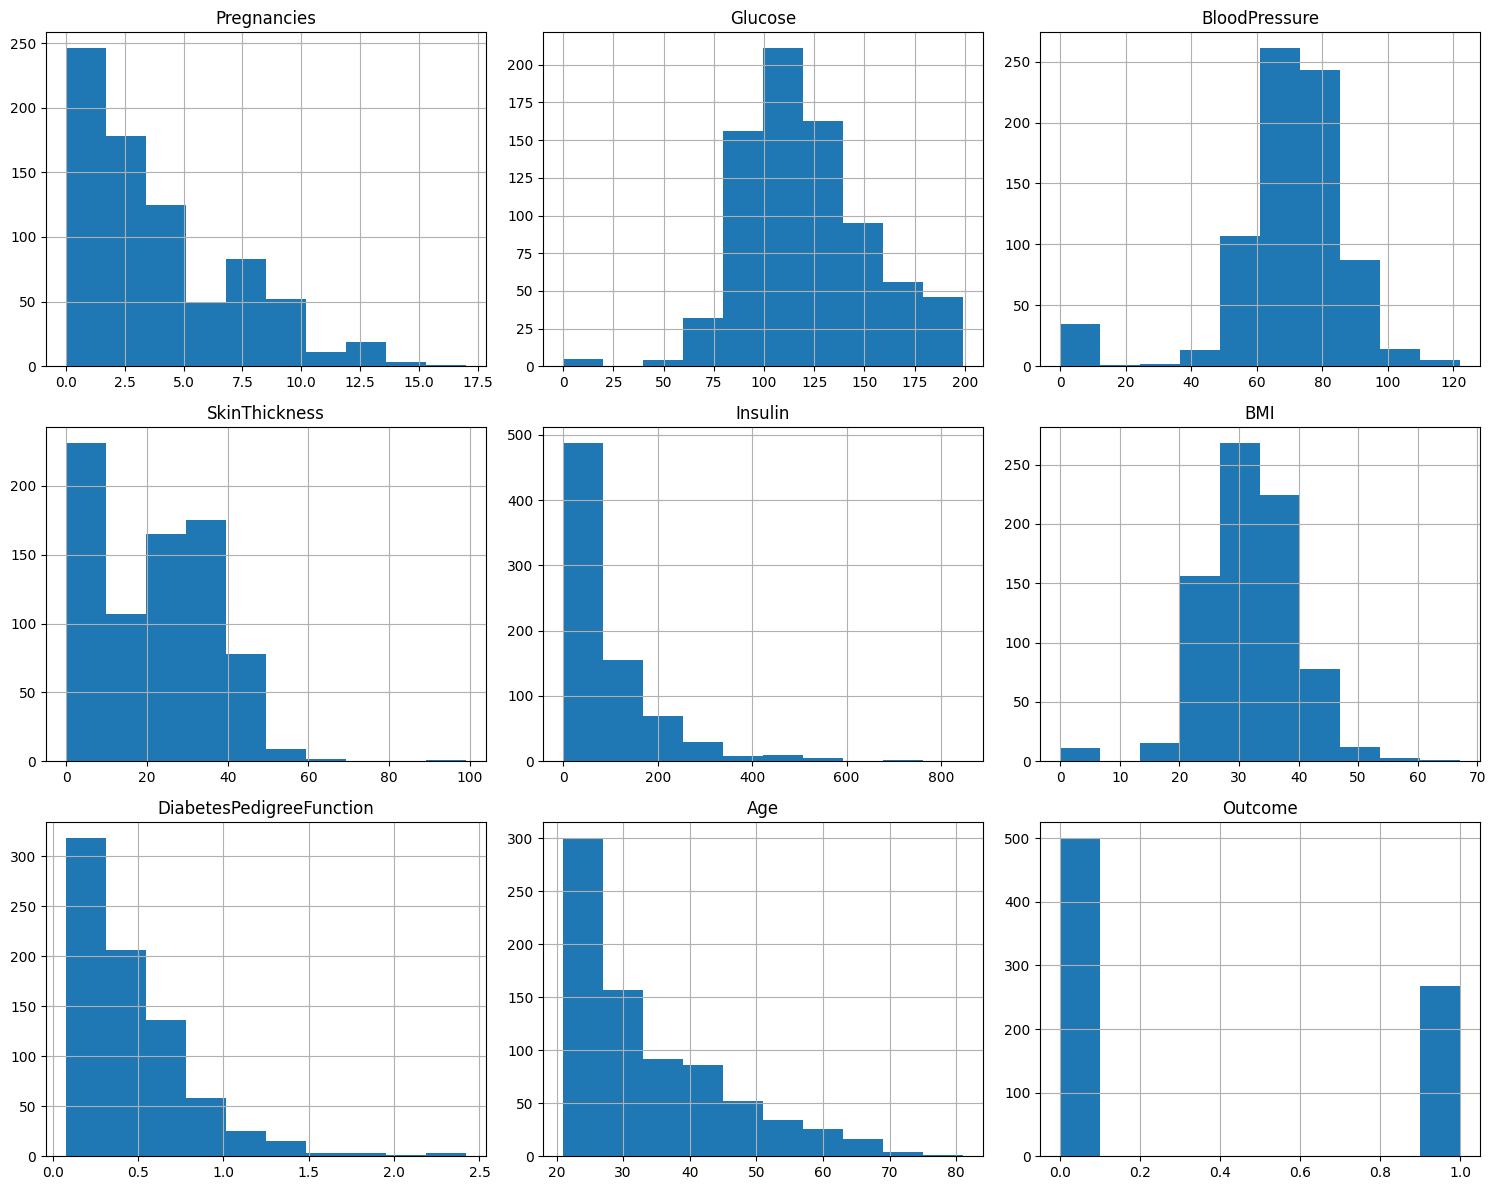

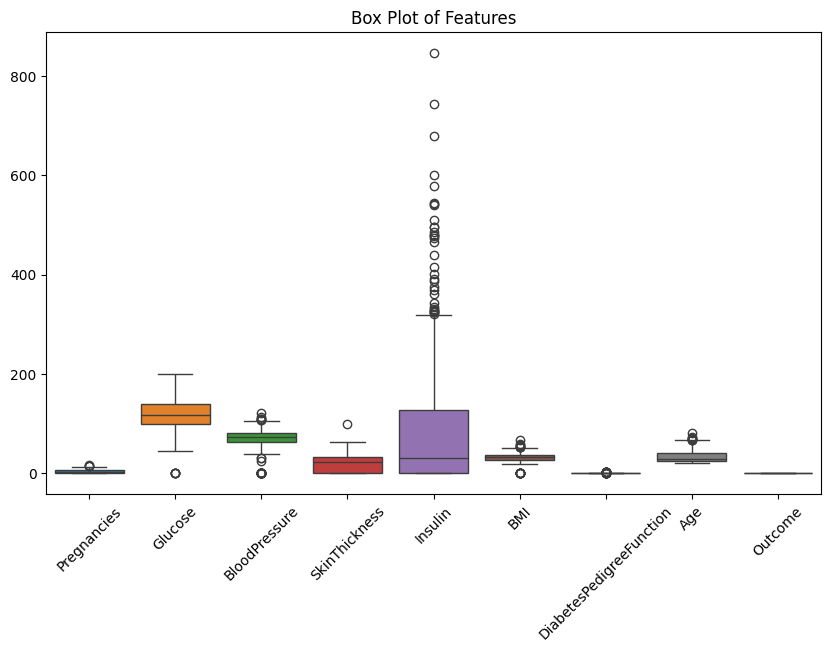

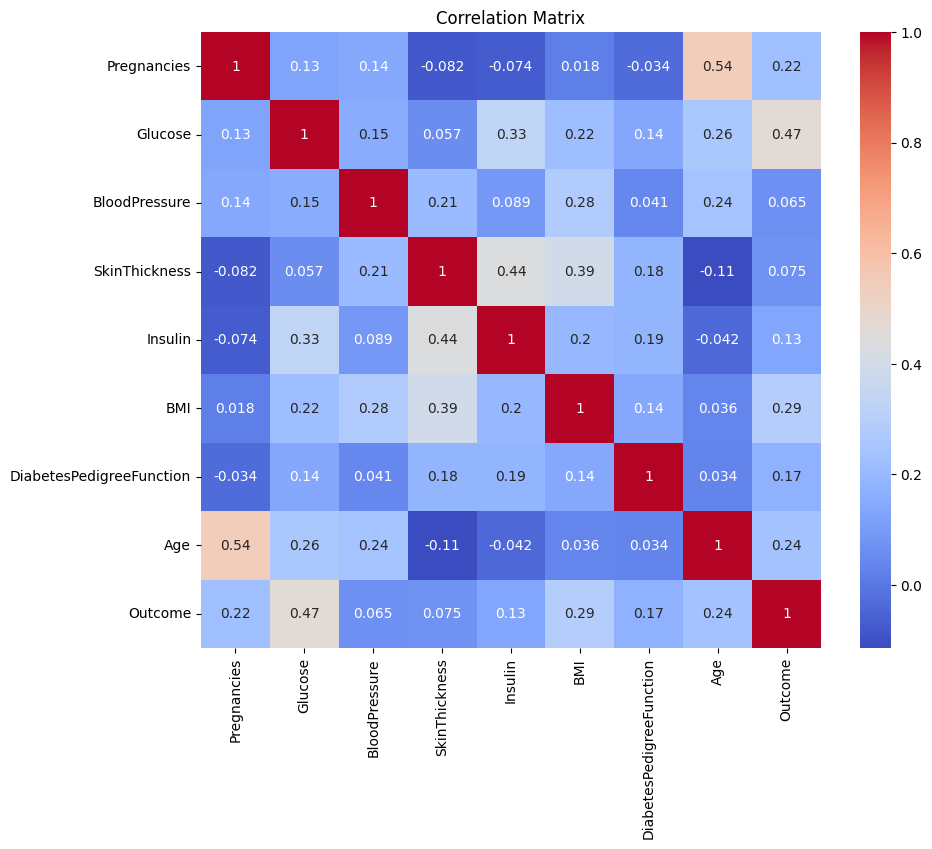

In [26]:
# Visualize feature distributions and correlations
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot of Features")
plt.show()
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [27]:
# Preprocess the data and handle missing values
X=df.drop(columns=["Outcome"])
y=df["Outcome"]
missing_values=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in missing_values:
    X[col]=X[col].replace(0,np.nan)
    X[col]=X[col].fillna(X[col].median())
print("Missing Values After Imputation:")
print(X.isnull().sum())
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

Missing Values After Imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
Training Samples: 614
Testing Samples: 154


In [28]:
# Build and train the Logistic Regression model
model=LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
y_prob=model.predict_proba(X_test_scaled)[:,1]
print("Model trained successfully.")
print(classification_report(y_test,y_pred))

Model trained successfully.
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [29]:
# Evaluate the Logistic Regression model
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_prob)
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1-Score:",f1)
print("ROC-AUC:",roc_auc)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1-Score: 0.5454545454545454
ROC-AUC: 0.812962962962963

Confusion Matrix:
[[82 18]
 [27 27]]


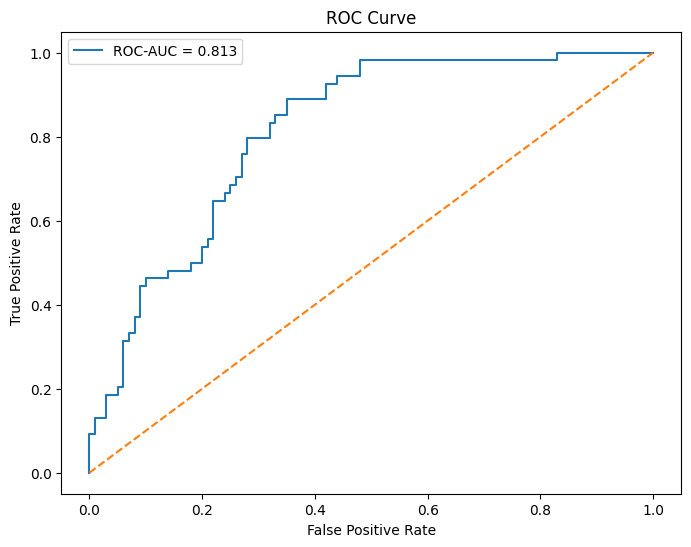

In [30]:
# Plot the ROC curve
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
# Interpret Logistic Regression coefficients
coefficient_df=pd.DataFrame({"Feature":X.columns,"Coefficient":model.coef_[0]})
coefficient_df["Odds_Ratio"]=np.exp(model.coef_[0])
coefficient_df["Absolute_Coefficient"]=abs(coefficient_df["Coefficient"])
coefficient_df=coefficient_df.sort_values("Absolute_Coefficient",ascending=False)
print(coefficient_df.drop(columns=["Absolute_Coefficient"]))

                    Feature  Coefficient  Odds_Ratio
1                   Glucose     1.182511    3.262558
5                       BMI     0.688735    1.991194
0               Pregnancies     0.377502    1.458637
6  DiabetesPedigreeFunction     0.233386    1.262869
7                       Age     0.147798    1.159279
4                   Insulin    -0.066157    0.935983
2             BloodPressure    -0.044066    0.956891
3             SkinThickness     0.028225    1.028627


In [32]:
# Save the trained model and scaler for Streamlit
joblib.dump(model,"logistic_model.pkl")
joblib.dump(scaler,"scaler.pkl")
print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [33]:
# Create the Streamlit application
app_code='''import streamlit as st
import pandas as pd
import joblib
st.title("Diabetes Prediction using Logistic Regression")
model=joblib.load("logistic_model.pkl")
scaler=joblib.load("scaler.pkl")
features=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
values=[]
for feature in features:
    value=st.number_input(feature,value=0.0)
    values.append(value)
if st.button("Predict"):
    input_data=pd.DataFrame([values],columns=features)
    input_scaled=scaler.transform(input_data)
    prediction=model.predict(input_scaled)[0]
    probability=model.predict_proba(input_scaled)[0][1]
    if prediction==1:
        st.error(f"Prediction: Diabetes detected. Probability: {probability:.2%}")
    else:
        st.success(f"Prediction: No diabetes detected. Probability: {probability:.2%}")
'''
with open("app.py","w") as f:
    f.write(app_code)
print("app.py created successfully.")

app.py created successfully.


In [34]:
# Verify files required for Streamlit
import os
print("Files:")
print(os.listdir())

Files:
['.config', 'scaler.pkl', 'logistic_model.pkl', 'app.py', 'streamlit.log', 'cloudflared', 'diabetes (1).csv', 'sample_data']


In [35]:
# Start the Streamlit application
!streamlit run app.py &>/content/streamlit.log &

In [36]:
# Install Cloudflare Tunnel
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [ ]:
# Create a public URL for the Streamlit app using Cloudflare Tunnel
import subprocess
import re
process=subprocess.Popen(["/content/cloudflared","tunnel","--url","http://localhost:8501"],stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
for line in process.stdout:
    if "trycloudflare.com" in line:
        print(line)

2026-09-29T17:53:01Z INF Requesting new quick Tunnel on trycloudflare.com...

2026-09-29T17:53:06Z INF |  https://stress-companies-cool-proposals.trycloudflare.com                                 |

